In [17]:
from pathlib import Path
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (accuracy_score, average_precision_score, f1_score,
                             log_loss, precision_score, recall_score, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


# 1. Loading Dataset

In [18]:
from pathlib import Path
from urllib.request import urlretrieve
import zipfile
import pandas as pd

#Using the dataset from the public Repo
DATA_URL = (
    "https://raw.githubusercontent.com/WebClub-NITK/"
    "Intelligence-SIG-Recs-2026/main/"
    "mandatory-tasks/recommender-systems-cf-to-dlrm/"
    "datasets/dataset%20%28tasks%202%20and%203%29.zip"
)

zip_path = Path("dataset_tasks_2_3.zip")

# Preventing re-downloading the dataset if the cell is run multiple times.
if not zip_path.exists():
    urlretrieve(DATA_URL, zip_path)
    print("Dataset downloaded.")
else:
    print("Using existing dataset ZIP.")

# Loading both CSV files from the ZIP
with zipfile.ZipFile(zip_path, "r") as archive:
    print("Files:", archive.namelist())
    train = pd.read_csv(archive.open("train.csv"))
    test = pd.read_csv(archive.open("test.csv"))

print(train.shape)
print(test.shape)

train.head()

Using existing dataset ZIP.
Files: ['train.csv', 'test.csv']
(40000, 40)
(10000, 40)


,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
0,0,49.0,520.0,0.0,353.0,5.0,0.0,0.0,0,2,...,1f7fc70b,628f1b8d,9512c20b,c5362157,a9ad4e8e,2b6a4b2f,bc71cd9d,9f4102b0,ff654802,2f33557c
1,0,NaN,408.0,NaN,NaN,NaN,0.0,0.0,-1,1,...,NaN,a1eb1511,0a1d513f,7fdb0729,747f6ecc,62682372,NaN,401a16fe,30436bfc,b757e957
2,0,28.0,37.0,2.0,5.0,4.0,5.0,1.0,974,14,...,753da5f3,d9f758ff,9512c20b,682d90ba,09afda28,307a0f03,f942364c,16e6b497,57e36578,a7ab145d
3,0,1.0,603.0,1.0,NaN,1.0,0.0,0.0,13,1,...,NaN,b8170bba,108a0699,47849e55,73b3f46d,d994ba60,NaN,328e967b,ff654802,2ba8d787
4,0,NaN,525.0,3.0,8.0,126.0,1.0,0.0,10,11,...,753da5f3,b8170bba,55191c09,0e29b5da,0683bc6f,47b99d80,d2b125b2,00a688ec,30436bfc,b757e957



# 2. EDA

In [19]:
num_cols = [f"integer_feature_{i}" for i in range(1, 14)]
cat_cols = [f"categorical_feature_{i}" for i in range(1, 27)]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Click-through rate:", f"{train['label'].mean():.2%}")
print("Duplicate training rows:", train.duplicated().sum())

numeric_eda = pd.DataFrame({
    "missing_%": (train[num_cols].isna().mean() * 100).round(2),
    "minus_one_count": train[num_cols].eq(-1).sum(),
    "zero_count": train[num_cols].eq(0).sum(),
    "min": train[num_cols].min(),
    "median": train[num_cols].median(),
    "max": train[num_cols].max(),
    "skew": train[num_cols].skew().round(2),
})

categorical_eda = pd.DataFrame({
    "missing_%": (train[cat_cols].isna().mean() * 100).round(2),
    "unique_categories": train[cat_cols].nunique(dropna=True),
})

display(numeric_eda)
display(categorical_eda.sort_values("unique_categories", ascending=False))

Train shape: (40000, 40)
Test shape: (10000, 40)
Click-through rate: 3.20%
Duplicate training rows: 0


,missing_%,minus_one_count,zero_count,min,median,max,skew
integer_feature_1,18.49,0,0,1.0,8.0,65535.0,108.24
integer_feature_2,8.69,0,0,1.0,177.0,8000.0,5.08
integer_feature_3,24.54,0,1526,0.0,4.0,491.0,7.57
integer_feature_4,39.99,0,1197,0.0,32.0,42898.0,25.50
integer_feature_5,38.53,0,0,1.0,6.0,2107.0,11.85
integer_feature_6,8.82,0,27062,0.0,0.0,288.0,11.58
integer_feature_7,3.03,0,36511,0.0,0.0,102.0,32.37
integer_feature_8,0.00,2455,7398,-1.0,5.0,8177.0,6.19
integer_feature_9,0.00,0,8497,0.0,5.0,50.0,1.48
integer_feature_10,8.82,0,28174,0.0,0.0,7.0,2.38


,missing_%,unique_categories
categorical_feature_20,4.05,13508
categorical_feature_1,4.05,13190
categorical_feature_22,4.05,12628
categorical_feature_10,4.05,11584
categorical_feature_21,4.05,9002
categorical_feature_12,0.00,7723
categorical_feature_11,4.05,5568
categorical_feature_23,36.36,5094
categorical_feature_3,0.00,4968
categorical_feature_5,0.00,4253


## 3. Train-Test Split & Preprocessing

For ad/CTR data with many high-cardinality categorical columns :

- Numeric missing values become the training median; then `log1p` reduces extreme numeric skew and `StandardScaler` puts columns on a comparable scale.
- Missing cateCategories appearing fewer than 10 times in the training split, and categories unseen in validation or test data become `__MISSING__`. Categories appearing fewer than 10 times in the training split, and categories unseen in validation or test data became `__UNKNOWN__`.
-Remaining frequent categories were encoded as integer IDs and passed to embedding layers. This reduces very large embedding tables and lowers the risk of overfitting to rare categories

Rare category embeddings receive too few updates to become meaningful, so grouping them as “unknown/rare” usually improves stability and memory use (due to the smaller embedding size).

In [20]:
SENTINEL = -1
MISSING = "__MISSING__"
MIN_COUNT = 10

# Keep the provided test set completely untouched until final evaluation.
X_train, X_val, y_train, y_val = train_test_split(
    train.drop(columns="label"),
    train["label"],
    test_size=0.20,
    random_state=SEED,
    stratify=train["label"],
)

# Numeric features:
# Treat -1 as missing, log-transform,
# then standardize using training statistics only.
train_numeric = X_train[num_cols].replace(SENTINEL, np.nan)
median = train_numeric.median()

scaler = StandardScaler().fit(
    np.log1p(train_numeric.fillna(median).clip(lower=0))
)

def scale_numeric(df):
    values = df[num_cols].replace(SENTINEL, np.nan)
    values = values.fillna(median).clip(lower=0)
    values = np.log1p(values)
    return scaler.transform(values).astype("float32")

X_train_num = scale_numeric(X_train)
X_val_num = scale_numeric(X_val)
X_test_num = scale_numeric(test)


# Categorical features:
# 0 = unknown or rare category
# 1 = missing category
# 2+ = frequent category observed in training
vocabs = {}

for col in cat_cols:
    values = X_train[col].fillna(MISSING).astype(str)
    counts = values.value_counts()

    frequent_values = counts[counts >= MIN_COUNT].index

    # Always retain missing as a separate signal.
    if MISSING not in frequent_values:
        frequent_values = frequent_values.insert(0, MISSING)

    vocabs[col] = frequent_values


def encode_categories(df):
    encoded_columns = []

    for col in cat_cols:
        values = df[col].fillna(MISSING).astype(str)

        # get_indexer returns -1 for unseen/rare values; +1 makes them 0.
        encoded = vocabs[col].get_indexer(values) + 1
        encoded_columns.append(encoded)

    return np.column_stack(encoded_columns).astype("int64")


X_train_cat = encode_categories(X_train)
X_val_cat = encode_categories(X_val)
X_test_cat = encode_categories(test)

# Embedding table size for each categorical feature.
cat_sizes = [len(vocabs[col]) + 1 for col in cat_cols]

print("Numeric matrices:", X_train_num.shape, X_val_num.shape, X_test_num.shape)
print("Categorical matrices:", X_train_cat.shape, X_val_cat.shape, X_test_cat.shape)
print("Largest embedding vocabulary:", max(cat_sizes))
print("Training click rate:", f"{y_train.mean():.2%}")
print("Validation click rate:", f"{y_val.mean():.2%}")

Numeric matrices: (32000, 13) (8000, 13) (10000, 13)
Categorical matrices: (32000, 26) (8000, 26) (10000, 26)
Largest embedding vocabulary: 645
Training click rate: 3.20%
Validation click rate: 3.20%


## 4. Vanilla neural networks

Each feature gets a small embedding, all embeddings are concatenated with the numeric inputs, and a compact dense network outputs click probability. We try three depth/width choices, with early stopping to expose overfitting through training and validation curves.

In [21]:
# Converts the numeric matrix and categorical ID matrix into named Keras inputs.
def make_inputs(numeric_matrix, categorical_matrix):
    return {
        "numeric": numeric_matrix,
        **{
            col: categorical_matrix[:, index].reshape(-1, 1)
            for index, col in enumerate(cat_cols)
        },
    }


def build_feature_inputs():
    numeric_input = tf.keras.Input(
        shape=(len(num_cols),),
        name="numeric"
    )

    inputs = {"numeric": numeric_input}
    feature_parts = [numeric_input]

    for col in cat_cols:
        # IDs: 0 = unknown/rare; 1..N = retained training categories.
        vocab_size = len(vocabs[col]) + 1
        embedding_size = min(8, max(2, int(np.ceil(np.log2(vocab_size)))))

        cat_input = tf.keras.Input(
            shape=(1,),
            dtype="int32",
            name=col
        )

        embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_size
        )(cat_input)

        inputs[col] = cat_input
        feature_parts.append(tf.keras.layers.Flatten()(embedding))

    combined_features = tf.keras.layers.Concatenate()(feature_parts)

    return inputs, combined_features


def build_mlp(hidden_layers, dropout=0.0):
    inputs, x = build_feature_inputs()

    for units in hidden_layers:
        x = tf.keras.layers.Dense(units, activation="relu")(x)

        if dropout > 0:
            x = tf.keras.layers.Dropout(dropout)(x)

    output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="roc_auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
            "accuracy",
        ],
    )

    return model


train_inputs = make_inputs(X_train_num, X_train_cat)
val_inputs = make_inputs(X_val_num, X_val_cat)
test_inputs = make_inputs(X_test_num, X_test_cat)

architectures = {
    "small [32]": ([32], 0.0),
    "medium [64, 32]": ([64, 32], 0.10),
    "wide [128, 64]": ([128, 64], 0.20),
}

models = {}
histories = {}
validation_auc = {}

for name, (layers, dropout) in architectures.items():
    model = build_mlp(layers, dropout)

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
    )

    history = model.fit(
        train_inputs,
        y_train,
        validation_data=(val_inputs, y_val),
        epochs=20,
        batch_size=512,
        verbose=0,
        callbacks=[early_stop],
    )

    models[name] = model
    histories[name] = history.history
    validation_auc[name] = max(history.history["val_roc_auc"])

    print(f"{name}: validation ROC-AUC = {validation_auc[name]:.4f}")

best_name = max(validation_auc, key=validation_auc.get)
best_model = models[best_name]

print(f"\nBest vanilla model: {best_name}")

small [32]: validation ROC-AUC = 0.7334
medium [64, 32]: validation ROC-AUC = 0.7298
wide [128, 64]: validation ROC-AUC = 0.7263

Best vanilla model: small [32]


## 5. A small Deep & Cross Network (DCN)

The vanilla MLP can learn feature interactions indirectly. DCN adds a small cross branch that explicitly multiplies the original feature vector by learned feature weights. This is a lightweight two-layer version of the Deep & Cross idea; it is included as a comparison, not as a complicated implementation.

In [22]:
class CrossLayer(tf.keras.layers.Layer):
    """
    Simple DCN cross layer:
    x_(l+1) = x_0 * (w_l^T x_l) + b_l + x_l
    """

    def build(self, input_shape):
        feature_count = int(input_shape[0][-1])

        self.cross_weight = self.add_weight(
            name="cross_weight",
            shape=(feature_count, 1),
            initializer="glorot_uniform",
            trainable=True,
        )

        self.cross_bias = self.add_weight(
            name="cross_bias",
            shape=(feature_count,),
            initializer="zeros",
            trainable=True,
        )

        super().build(input_shape)

    def call(self, inputs):
        x0, x = inputs

        # Shape: (batch_size, 1)
        projection = tf.matmul(x, self.cross_weight)

        return x0 * projection + self.cross_bias + x


def build_dcn(cross_layers=2):
    inputs, x0 = build_feature_inputs()

    # Explicit feature-interaction branch.
    cross = x0
    for _ in range(cross_layers):
        cross = CrossLayer()([x0, cross])

    # Small ordinary neural-network branch.
    deep = tf.keras.layers.Dense(64, activation="relu")(x0)
    deep = tf.keras.layers.Dense(32, activation="relu")(deep)

    # Combine explicit crosses and learned deep interactions.
    combined = tf.keras.layers.Concatenate()([cross, deep])
    output = tf.keras.layers.Dense(1, activation="sigmoid")(combined)

    model = tf.keras.Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="roc_auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
            "accuracy",
        ],
    )

    return model


dcn_model = build_dcn(cross_layers=2)

dcn_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_roc_auc",
    mode="max",
    patience=3,
    restore_best_weights=True,
)

dcn_history = dcn_model.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=20,
    batch_size=512,
    verbose=0,
    callbacks=[dcn_early_stop],
)

dcn_val_auc = max(dcn_history.history["val_roc_auc"])

print(f"Best vanilla validation ROC-AUC: {validation_auc[best_name]:.4f}")
print(f"DCN validation ROC-AUC: {dcn_val_auc:.4f}")

Best vanilla validation ROC-AUC: 0.7334
DCN validation ROC-AUC: 0.7194


## 6. Test metrics and calibration

A CTR is usually imbalanced, so ROC-AUC alone is incomplete. We also report PR-AUC and log loss. The threshold is chosen on validation data by maximizing F1, then applied unchanged to test predictions. The reliability plot checks whether predicted probabilities match observed click frequency.

Selected using validation ROC-AUC: Vanilla MLP (small [32])


,Model,Validation ROC-AUC,Test ROC-AUC,Accuracy,PR-AUC,Log loss,F1,Precision,Recall,F1 threshold
0,Vanilla MLP (small [32]),0.7334,0.6876,0.9113,0.0729,0.1393,0.1227,0.0917,0.1851,0.08
1,DCN (2 cross layers),0.7194,0.6843,0.8612,0.0658,0.1399,0.1193,0.0757,0.2806,0.07


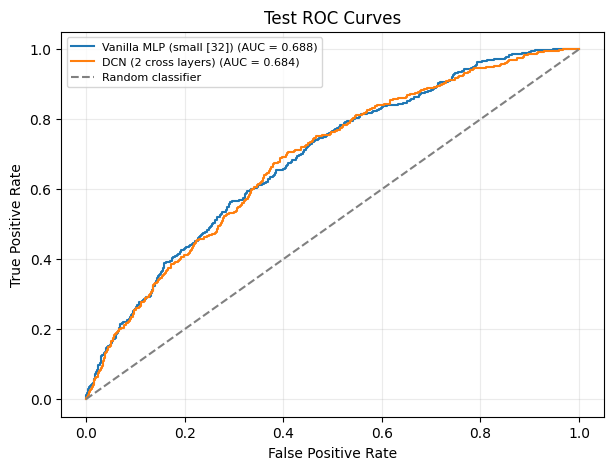

In [25]:
# Select the final model using validation ROC-AUC only.
candidates = {
    f"Vanilla MLP ({best_name})": (best_model, validation_auc[best_name]),
    "DCN (2 cross layers)": (dcn_model, dcn_val_auc),
}

selected_name = max(candidates, key=lambda name: candidates[name][1])
print("Selected using validation ROC-AUC:", selected_name)

# The supplied test set is used only here.
y_test = test["label"].to_numpy()

# Select an F1 threshold separately for each model using validation data only.
thresholds = np.linspace(0.05, 0.95, 181)

rows = []
test_probabilities = {}

for name, (model, val_auc) in candidates.items():
    val_probability = model.predict(val_inputs, verbose=0).ravel()

    best_threshold = max(
        thresholds,
        key=lambda threshold: f1_score(y_val, val_probability >= threshold),
    )

    test_probability = model.predict(test_inputs, verbose=0).ravel()
    test_prediction = (test_probability >= best_threshold).astype(int)

    test_probabilities[name] = test_probability

    rows.append({
        "Model": name,
        "Validation ROC-AUC": val_auc,
        "Test ROC-AUC": roc_auc_score(y_test, test_probability),
        "Accuracy": accuracy_score(y_test, test_prediction),
        "PR-AUC": average_precision_score(y_test, test_probability),
        "Log loss": log_loss(y_test, test_probability),
        "F1": f1_score(y_test, test_prediction),
        "Precision": precision_score(y_test, test_prediction, zero_division=0),
        "Recall": recall_score(y_test, test_prediction, zero_division=0),
        "F1 threshold": best_threshold,
    })

metrics = (
    pd.DataFrame(rows)
    .sort_values("Validation ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(
    metrics.style
    .format({
        "Validation ROC-AUC": "{:.4f}",
        "Test ROC-AUC": "{:.4f}",
        "Accuracy": "{:.4f}",
        "PR-AUC": "{:.4f}",
        "Log loss": "{:.4f}",
        "F1": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 threshold": "{:.2f}",
    })
    .highlight_max(
        subset=["Validation ROC-AUC", "Test ROC-AUC", "PR-AUC", "F1"],
        color="#C6EFCE",
    )
)

# Calibration is shown only for the model selected on validation data.
selected_probability = test_probabilities[selected_name]

fraction_positive, mean_predicted = calibration_curve(
    y_test,
    selected_probability,
    n_bins=10,
    strategy="quantile",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Reliability / calibration plot
axes[0].plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Perfect calibration",
)
axes[0].plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    color="#2878B5",
    label=selected_name,
)
axes[0].set_title("Reliability plot")
axes[0].set_xlabel("Mean predicted click probability")
axes[0].set_ylabel("Observed click frequency")
axes[0].grid(alpha=0.25)
axes[0].legend()

# ROC curves for vanilla and DCN
for name, probability in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probability)

    auc_value = metrics.loc[
        metrics["Model"] == name,
        "Test ROC-AUC"
    ].iloc[0]

    axes[1].plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_value:.3f})",
    )

axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Test ROC curves")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# **CONCLUSION**

Vanilla NN is preferred over DCN.

Adding explicit feature crosses did not improve CTR ranking quality. The vanilla MLP likely learned sufficient useful interactions implicitly through its dense layers, while the DCN’s explicit cross layers added extra constraints and complexity without producing a better validation result. This shows that DCN is not automatically superior; its benefit depends on the dataset, feature interactions, and hyperparameters.

The vanilla MLP also has higher test ROC-AUC and PR-AUC, it is the preferred model because it provides better performance with a simpler architecture.